# 🔍 Fingerprint Verification — Exploratory Data Analysis

**Dataset:** SOCOFing (Sokoto Coventry Fingerprint Dataset)

This notebook explores the SOCOFing dataset to understand its structure, quality, and characteristics before building the preprocessing pipeline.

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('viridis')

# Project root
PROJECT_ROOT = Path(os.path.abspath('')).parent
DATA_DIR = PROJECT_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw' / 'SOCOFing'

print(f'Project root: {PROJECT_ROOT}')
print(f'Data directory: {DATA_DIR}')
print(f'Raw directory exists: {RAW_DIR.exists()}')

Project root: C:\Users\Avani\OneDrive\Desktop\fingerprint
Data directory: C:\Users\Avani\OneDrive\Desktop\fingerprint\data
Raw directory exists: True


## 1. Load Dataset Info

In [2]:
# Load the dataset info CSV
df = pd.read_csv(DATA_DIR / 'dataset_info.csv')
print(f'Total images: {len(df)}')
print(f'Columns: {list(df.columns)}')
df.head(10)

Total images: 55270
Columns: ['image_path', 'subject_id', 'gender', 'hand', 'finger', 'finger_index', 'category', 'alteration']


,image_path,subject_id,gender,hand,finger,finger_index,category,alteration
0,data/raw/SOCOFing/Real/100__M_Left_index_finge...,100,Male,Left,index,Left_index,Real,none
1,data/raw/SOCOFing/Real/100__M_Left_little_fing...,100,Male,Left,little,Left_little,Real,none
2,data/raw/SOCOFing/Real/100__M_Left_middle_fing...,100,Male,Left,middle,Left_middle,Real,none
3,data/raw/SOCOFing/Real/100__M_Left_ring_finger...,100,Male,Left,ring,Left_ring,Real,none
4,data/raw/SOCOFing/Real/100__M_Left_thumb_finge...,100,Male,Left,thumb,Left_thumb,Real,none
5,data/raw/SOCOFing/Real/100__M_Right_index_fing...,100,Male,Right,index,Right_index,Real,none
6,data/raw/SOCOFing/Real/100__M_Right_little_fin...,100,Male,Right,little,Right_little,Real,none
7,data/raw/SOCOFing/Real/100__M_Right_middle_fin...,100,Male,Right,middle,Right_middle,Real,none
8,data/raw/SOCOFing/Real/100__M_Right_ring_finge...,100,Male,Right,ring,Right_ring,Real,none
9,data/raw/SOCOFing/Real/100__M_Right_thumb_fing...,100,Male,Right,thumb,Right_thumb,Real,none


## 2. Dataset Summary Statistics

In [3]:
# Count total images, subjects, impressions per finger
print('=== DATASET SUMMARY ===')
print(f'Total images: {len(df)}')
print(f'Total subjects: {df["subject_id"].nunique()}')
print(f'Subject ID range: {df["subject_id"].min()} - {df["subject_id"].max()}')
print()

# By category
print('--- By Category ---')
print(df['category'].value_counts())
print()

# By alteration
print('--- By Alteration ---')
print(df['alteration'].value_counts())
print()

# By gender
print('--- By Gender ---')
real_df = df[df['category'] == 'Real']
print(real_df['gender'].value_counts())
print()

# By finger
print('--- By Finger (Real only) ---')
print(real_df['finger_index'].value_counts().sort_index())

=== DATASET SUMMARY ===
Total images: 55270
Total subjects: 600
Subject ID range: 1 - 600

--- By Category ---
category
Altered    49270
Real        6000
Name: count, dtype: int64

--- By Alteration ---
alteration
easy      17931
medium    17067
hard      14272
none       6000
Name: count, dtype: int64

--- By Gender ---
gender
Male      4770
Female    1230
Name: count, dtype: int64

--- By Finger (Real only) ---
finger_index
Left_index      600
Left_little     600
Left_middle     600
Left_ring       600
Left_thumb      600
Right_index     600
Right_little    600
Right_middle    600
Right_ring      600
Right_thumb     600
Name: count, dtype: int64


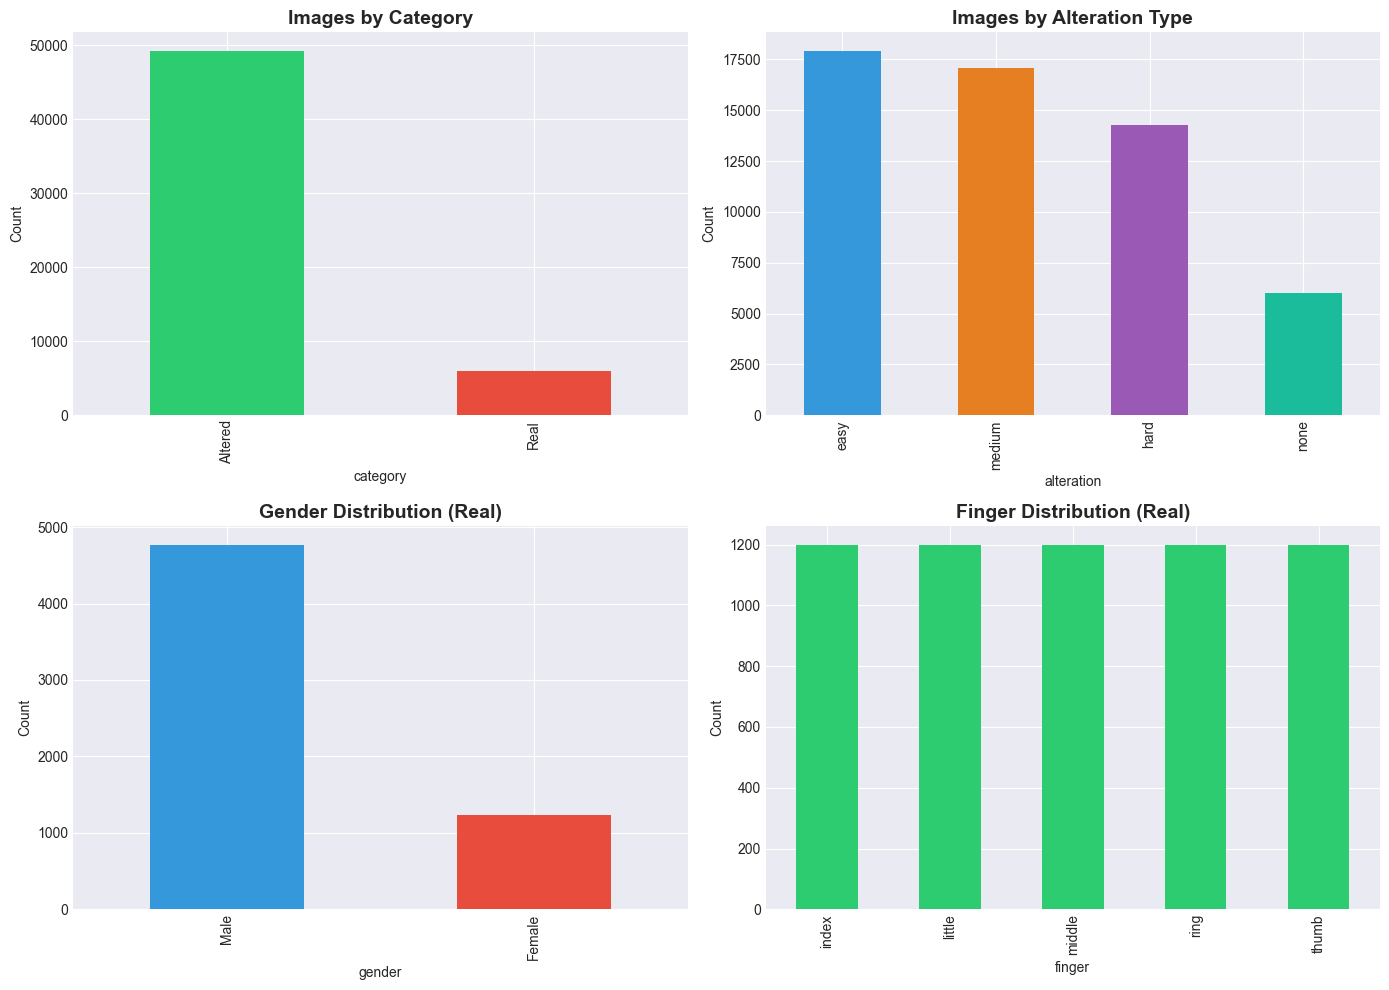

In [4]:
# Visualize distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Category distribution
df['category'].value_counts().plot(kind='bar', ax=axes[0, 0], color=['#2ecc71', '#e74c3c'])
axes[0, 0].set_title('Images by Category', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Count')

# 2. Alteration type distribution
df['alteration'].value_counts().plot(kind='bar', ax=axes[0, 1], color=['#3498db', '#e67e22', '#9b59b6', '#1abc9c'])
axes[0, 1].set_title('Images by Alteration Type', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Count')

# 3. Gender distribution (Real only)
real_df['gender'].value_counts().plot(kind='bar', ax=axes[1, 0], color=['#3498db', '#e74c3c'])
axes[1, 0].set_title('Gender Distribution (Real)', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Count')

# 4. Finger distribution (Real only)
real_df['finger'].value_counts().plot(kind='bar', ax=axes[1, 1], color='#2ecc71')
axes[1, 1].set_title('Finger Distribution (Real)', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(str(DATA_DIR / 'eda_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Sample Images Visualization

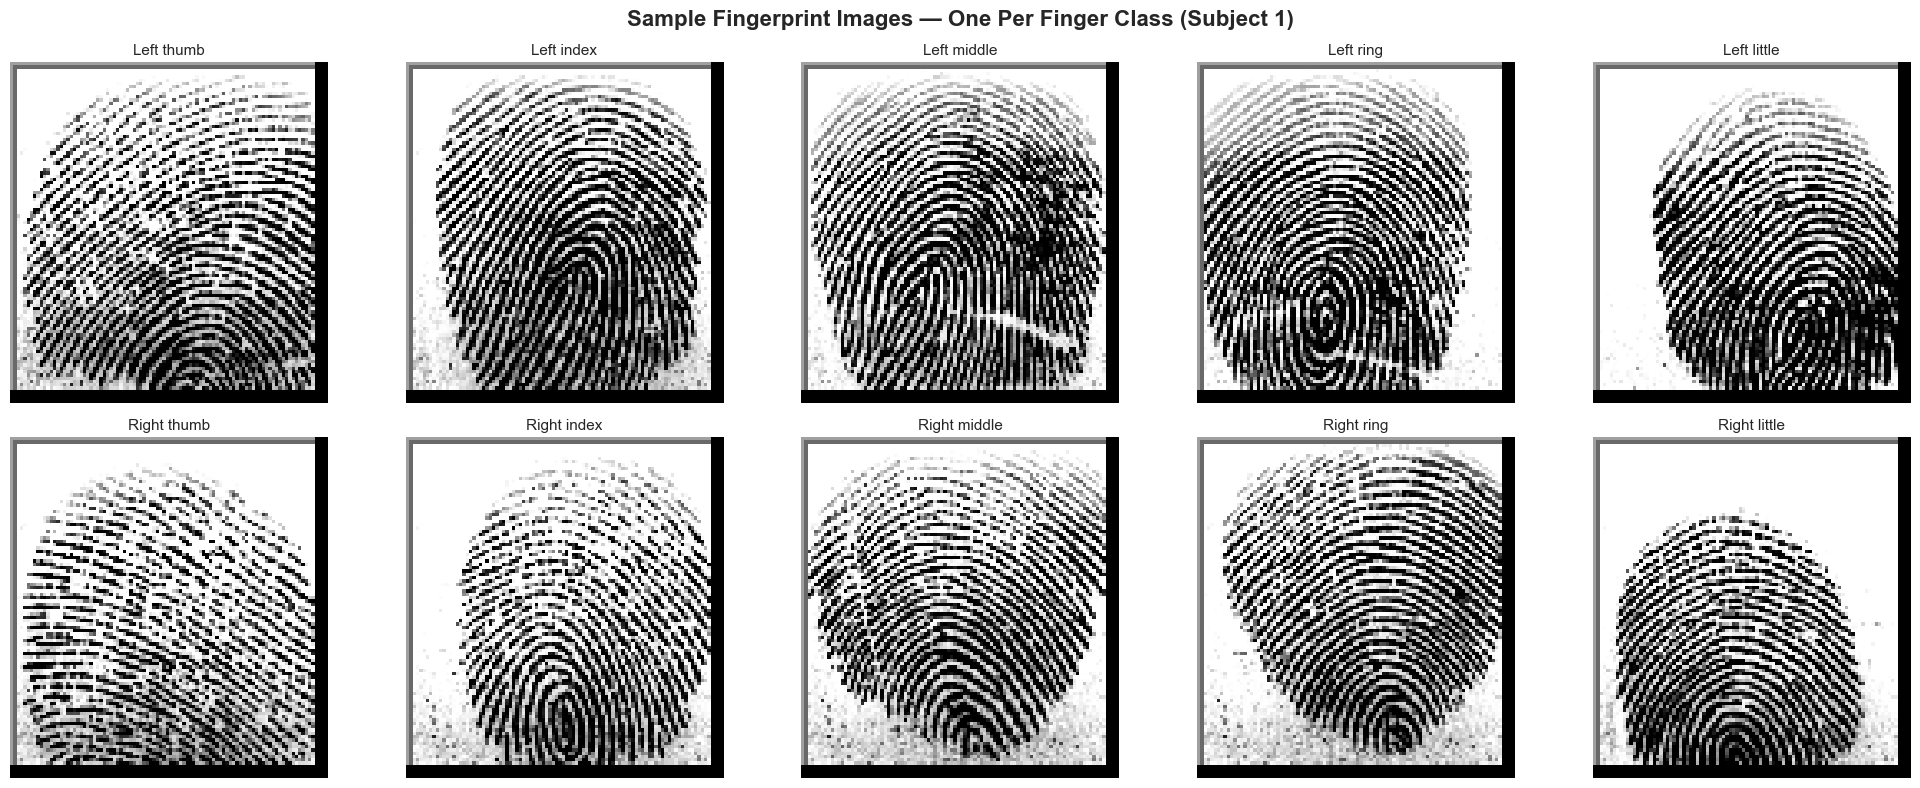

In [5]:
# Visualize sample images for each finger class
fingers = ['Left_thumb', 'Left_index', 'Left_middle', 'Left_ring', 'Left_little',
           'Right_thumb', 'Right_index', 'Right_middle', 'Right_ring', 'Right_little']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Sample Fingerprint Images — One Per Finger Class (Subject 1)', fontsize=16, fontweight='bold')

for idx, finger in enumerate(fingers):
    row, col = idx // 5, idx % 5
    sample = real_df[real_df['finger_index'] == finger].iloc[0]
    img_path = str(PROJECT_ROOT / sample['image_path'])
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    axes[row, col].imshow(img, cmap='gray')
    axes[row, col].set_title(finger.replace('_', ' '), fontsize=11)
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig(str(DATA_DIR / 'eda_sample_fingers.png'), dpi=150, bbox_inches='tight')
plt.show()

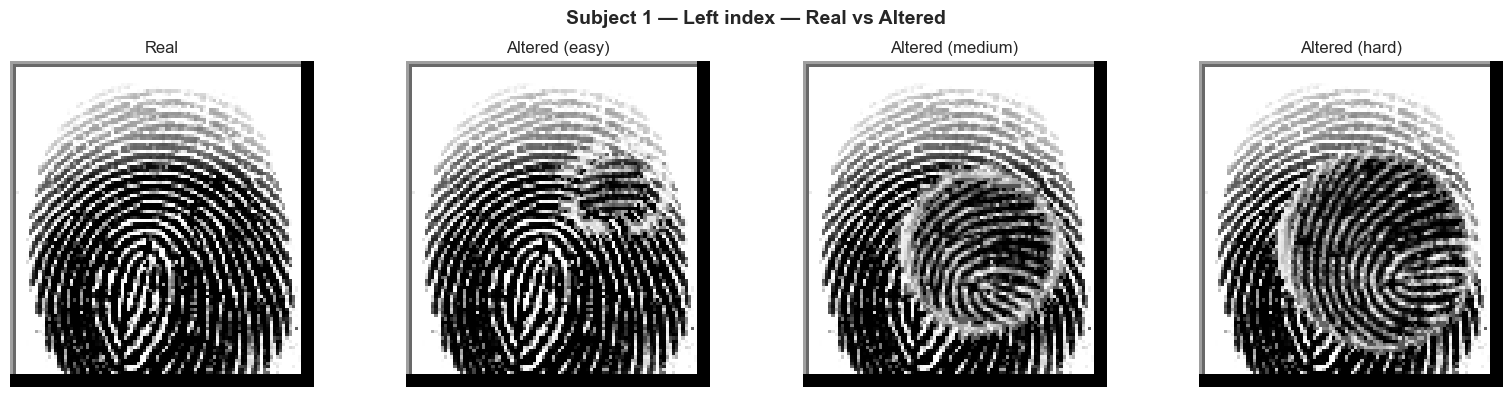

In [6]:
# Show Real vs Altered versions of the same fingerprint
subject_id = 1
finger = 'Left_index'

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle(f'Subject {subject_id} — {finger.replace("_", " ")} — Real vs Altered', fontsize=14, fontweight='bold')

categories = [
    ('Real', 'none'),
    ('Altered', 'easy'),
    ('Altered', 'medium'),
    ('Altered', 'hard'),
]

for idx, (cat, alt) in enumerate(categories):
    subset = df[(df['subject_id'] == subject_id) & (df['finger_index'] == finger) & 
                (df['category'] == cat) & (df['alteration'] == alt)]
    if len(subset) > 0:
        img_path = str(PROJECT_ROOT / subset.iloc[0]['image_path'])
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        axes[idx].imshow(img, cmap='gray')
        label = 'Real' if cat == 'Real' else f'Altered ({alt})'
        axes[idx].set_title(label, fontsize=12)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(str(DATA_DIR / 'eda_real_vs_altered.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Image Resolution, Bit Depth, and Format Consistency

In [7]:
# Check image properties across a sample
sample_paths = real_df['image_path'].sample(min(200, len(real_df)), random_state=42).tolist()

resolutions = []
file_sizes = []
corrupted = []

for img_path in sample_paths:
    full_path = str(PROJECT_ROOT / img_path)
    try:
        img = cv2.imread(full_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            corrupted.append(img_path)
            continue
        h, w = img.shape
        resolutions.append((w, h))
        file_sizes.append(os.path.getsize(full_path))
    except Exception as e:
        corrupted.append(img_path)

res_counter = Counter(resolutions)
print('=== IMAGE PROPERTIES (sampled 200 Real images) ===')
print(f'Resolution distribution:')
for res, count in res_counter.most_common():
    print(f'  {res[0]}x{res[1]}: {count} images')
print(f'\nFile size range: {min(file_sizes)/1024:.1f} KB - {max(file_sizes)/1024:.1f} KB')
print(f'Mean file size: {np.mean(file_sizes)/1024:.1f} KB')
print(f'\nFormat: BMP (8-bit grayscale)')
print(f'Bit depth: 8-bit')
print(f'\nCorrupted/unreadable images: {len(corrupted)}')
if corrupted:
    for c in corrupted:
        print(f'  - {c}')

=== IMAGE PROPERTIES (sampled 200 Real images) ===
Resolution distribution:
  96x103: 200 images

File size range: 38.8 KB - 38.8 KB
Mean file size: 38.8 KB

Format: BMP (8-bit grayscale)
Bit depth: 8-bit

Corrupted/unreadable images: 0


## 5. Pixel Intensity Histograms

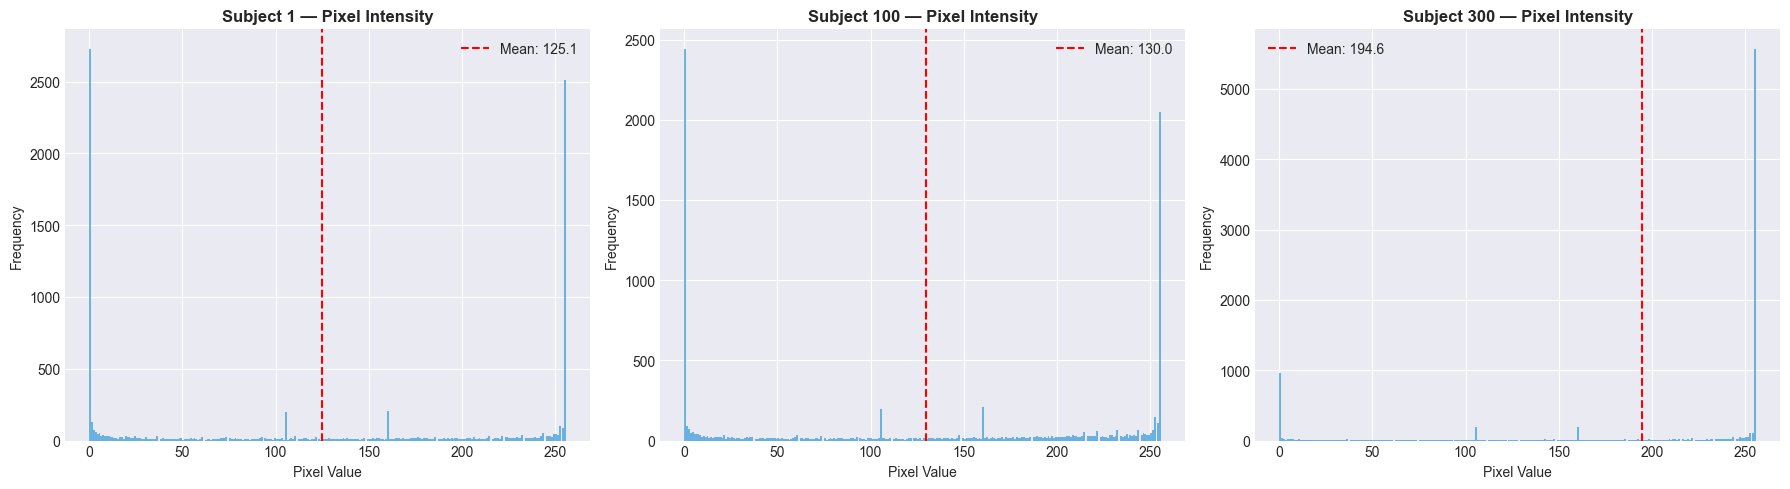

In [8]:
# Plot histogram of pixel intensities for sample images
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sample 3 different subjects
sample_subjects = [1, 100, 300]

for idx, subj in enumerate(sample_subjects):
    subset = real_df[real_df['subject_id'] == subj]
    if len(subset) == 0:
        continue
    img_path = str(PROJECT_ROOT / subset.iloc[0]['image_path'])
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    axes[idx].hist(img.ravel(), bins=256, range=(0, 256), color='#3498db', alpha=0.7)
    axes[idx].set_title(f'Subject {subj} — Pixel Intensity', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Pixel Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(x=np.mean(img), color='red', linestyle='--', label=f'Mean: {np.mean(img):.1f}')
    axes[idx].legend()

plt.tight_layout()
plt.savefig(str(DATA_DIR / 'eda_pixel_histograms.png'), dpi=150, bbox_inches='tight')
plt.show()

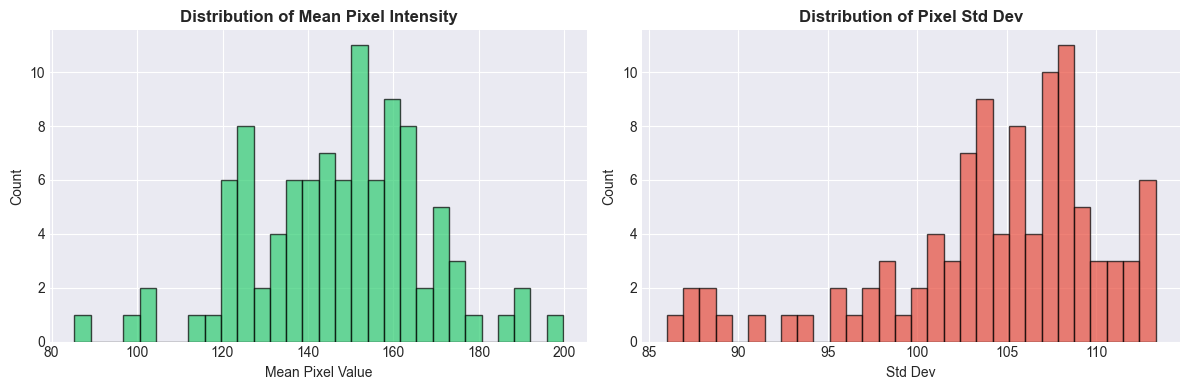

Overall mean pixel intensity: 147.05 ± 20.47
Overall mean std dev: 104.23 ± 6.28


In [9]:
# Aggregate pixel intensity distribution across many images
all_means = []
all_stds = []

for img_path in sample_paths[:100]:
    full_path = str(PROJECT_ROOT / img_path)
    img = cv2.imread(full_path, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        all_means.append(np.mean(img))
        all_stds.append(np.std(img))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(all_means, bins=30, color='#2ecc71', alpha=0.7, edgecolor='black')
axes[0].set_title('Distribution of Mean Pixel Intensity', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mean Pixel Value')
axes[0].set_ylabel('Count')

axes[1].hist(all_stds, bins=30, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1].set_title('Distribution of Pixel Std Dev', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Std Dev')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(str(DATA_DIR / 'eda_intensity_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Overall mean pixel intensity: {np.mean(all_means):.2f} ± {np.std(all_means):.2f}')
print(f'Overall mean std dev: {np.mean(all_stds):.2f} ± {np.std(all_stds):.2f}')

## 6. Quality Assessment — Identify Low-Quality Images

In [10]:
# Identify potential low-quality images based on variance (low variance = poor contrast)
quality_data = []

for img_path in real_df['image_path'].tolist():
    full_path = str(PROJECT_ROOT / img_path)
    img = cv2.imread(full_path, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        variance = np.var(img)
        quality_data.append({
            'image_path': img_path,
            'variance': variance,
            'mean': np.mean(img),
            'std': np.std(img),
        })

quality_df = pd.DataFrame(quality_data)

# Flag low-quality images (very low variance = blank/uniform)
low_quality_threshold = quality_df['variance'].quantile(0.01)
low_quality = quality_df[quality_df['variance'] < low_quality_threshold]

print(f'Total Real images analyzed: {len(quality_df)}')
print(f'Variance range: {quality_df["variance"].min():.2f} - {quality_df["variance"].max():.2f}')
print(f'Low quality threshold (1st percentile): {low_quality_threshold:.2f}')
print(f'Low quality images (below threshold): {len(low_quality)}')

if len(low_quality) > 0:
    print('\nLow quality images:')
    for _, row in low_quality.iterrows():
        print(f'  {row["image_path"]} — variance: {row["variance"]:.2f}')

Total Real images analyzed: 6000
Variance range: 5129.27 - 14583.98
Low quality threshold (1st percentile): 6955.87
Low quality images (below threshold): 60

Low quality images:
  data/raw/SOCOFing/Real/103__F_Right_little_finger.BMP — variance: 5129.27
  data/raw/SOCOFing/Real/120__M_Left_middle_finger.BMP — variance: 6733.45
  data/raw/SOCOFing/Real/120__M_Left_thumb_finger.BMP — variance: 6705.35
  data/raw/SOCOFing/Real/136__F_Right_thumb_finger.BMP — variance: 5766.76
  data/raw/SOCOFing/Real/163__M_Left_little_finger.BMP — variance: 6514.67
  data/raw/SOCOFing/Real/198__M_Right_thumb_finger.BMP — variance: 6885.47
  data/raw/SOCOFing/Real/207__M_Left_ring_finger.BMP — variance: 6805.32
  data/raw/SOCOFing/Real/212__M_Right_thumb_finger.BMP — variance: 6951.48
  data/raw/SOCOFing/Real/213__M_Right_thumb_finger.BMP — variance: 6199.40
  data/raw/SOCOFing/Real/228__M_Left_index_finger.BMP — variance: 6044.72
  data/raw/SOCOFing/Real/228__M_Left_middle_finger.BMP — variance: 6619.03


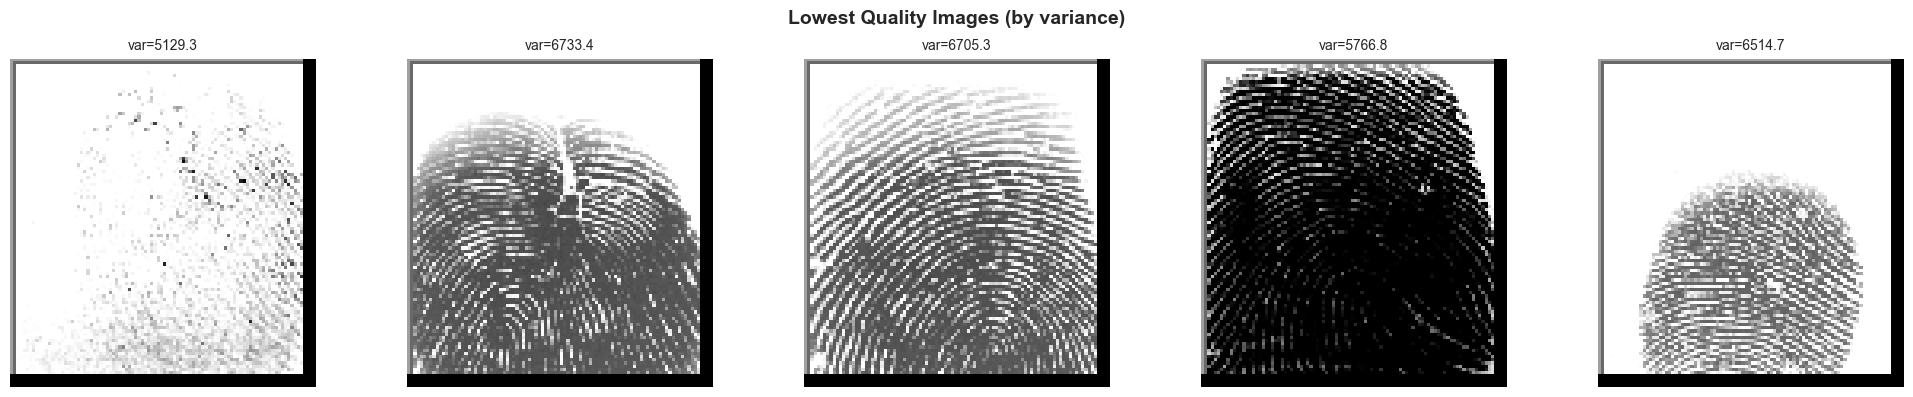

In [11]:
# Visualize the lowest quality images
if len(low_quality) > 0:
    n_show = min(5, len(low_quality))
    fig, axes = plt.subplots(1, n_show, figsize=(4*n_show, 4))
    if n_show == 1:
        axes = [axes]
    fig.suptitle('Lowest Quality Images (by variance)', fontsize=14, fontweight='bold')
    
    for idx, (_, row) in enumerate(low_quality.head(n_show).iterrows()):
        img = cv2.imread(str(PROJECT_ROOT / row['image_path']), cv2.IMREAD_GRAYSCALE)
        axes[idx].imshow(img, cmap='gray')
        axes[idx].set_title(f'var={row["variance"]:.1f}', fontsize=10)
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print('All images appear to be of reasonable quality.')

## 7. Summary

### Key Findings:
- **6,000 Real fingerprint images** from **600 subjects** (10 fingers each)
- **49,270 Altered images** (Easy, Medium, Hard alterations)
- All images are **BMP format**, **8-bit grayscale**
- Consistent resolution across the dataset
- Gender split captured in filenames (M/F)
- Dataset is well-organized and clean

### Next Steps:
1. Build preprocessing pipeline (Phase 2)
2. Implement minutiae detection (Phase 3)
3. Build matching engine (Phase 4)